### Section 1 — Data processing (4a)
* Load “official” BEA-style profit series (Excel) and alternative profit CSVs.
* Standardize columns: Year→year, Country→country, profit variable→pi.
* Merge and prioritize the official series where overlaps exist.
* Load a price index and compute inflation = 100 * Δlog(price_index).
* Load growth controls (row_growth, us_growth).
* Build a tidy modeling DataFrame df_model with: share_raw (from pi), controls, price_index
* Save for the analsis (4b)

In [6]:
from __future__ import annotations
from pathlib import Path
from typing import List, Optional

import numpy as np
import pandas as pd
# Country→ISO mapping and your exact manual fixes
from data_processing import get_iso3

from datetime import datetime
import wbdata as wb



pd.set_option("display.max_columns", 50)

# === File paths used in your script ===
BEA_DATASET_TSV: Path = Path("data/bea_dataset.tsv")  # relative (as in your code)
FRED_DOLLAR_INDEX_CSV: Path = Path("data_raw/fred_dollar_index/fredgraph_perc.csv")  # relative

# BEA files under your base path
INCOME_XLSX: Path = Path("data_raw/IncomeStatement98INTERP.xlsx")
PROFIT_CSVS: List[Path] = [
    Path("data_raw/ProfitType98INTERP.csv"),
    Path("data_raw/ProfitType08INTERP.csv"),
    Path("data_raw/ProfitType18INTERP.csv")
]

# GJZ US profits workbook (
GJZ_XLSX: Path = Path("data/GJZ2021Data.xlsx")

# === NEW: put your exchange-rate file path here (nominal LCU/USD, period average) ===
# EDIT to your actual file if different; the code expects a wide GEM-like sheet with "Country", "Series", and year columns like "2010 [2010]"
EXCHANGE_GEM_XLSX: Optional[Path] = "data_raw/exchange_rates_P_Data_Extract_From_Global_Economic_Monitor_(GEM).xlsx"
rate = "Official exchange rate, LCU per USD, period average,," # old currency, but problems iin south-american currencies during redenominationsdf_exchange_m = df_exchange_m.loc[df_exchange_m["Series"] == rate]




In [7]:
# === DATA PROCESSING (1/3): READ BEA DATA ===
# Build a unified iso–year–pi panel following your script logic.

# 1) Base BEA tsv used in your code (source == "BEA_return")
df_src: pd.DataFrame = pd.read_csv(BEA_DATASET_TSV, sep="\t")
df_src = df_src.loc[df_src["source"] == "BEA_return", ["iso", "year", "pi"]].copy()
# Share of foreign profits
x = df_src.loc[df_src["iso"].isin(["Rest", "USA"])]
x = pd.pivot_table(x, values="pi", index="year", columns=["iso"])
x["sahre"] = x["Rest"] / (x["Rest"] + x["USA"])
display(x)

# Add a new country "Others" fwith the missing profits (in categories such as "Other Western")
df_others = pd.concat([ 
                    df_src.loc[df_src["iso"]=="Rest"].set_index("year"),
                    df_src.loc[~df_src["iso"].isin({"USA", "Rest"})].groupby("year").sum(numeric_only=True)
                    ],
                  axis=1)
df_others.columns = ["iso","pirest","pi_ind"]
df_others["iso"] = "Others"
df_others["pi"] = df_others["pirest"] - df_others["pi_ind"]
df_src = df_src.loc[df_src["iso"] != "Rest"]
df_src = pd.concat([df_src, df_others.reset_index()[["iso","year","pi"]]])



# 2) “Official” Excel + alternative CSVs (your exact columns)
df1 = pd.read_excel(INCOME_XLSX, usecols=["Year", "Country", "Calculated Profit-type return"]).rename(
    columns={"Year": "year", "Country": "country", "Calculated Profit-type return": "pi"}
)
alts: List[pd.DataFrame] = []
for p in PROFIT_CSVS:
    t = pd.read_csv(p, usecols=["Year", "Country", "All Industries"]).rename(
        columns={"Year": "year", "Country": "country", "All Industries": "pi"}
    )
    alts.append(t)
df2 = pd.concat(alts, ignore_index=True)

# 3) Prioritize official where overlapping, then map to iso and aggregate
m = pd.merge(df2, df1, on=["year", "country"], how="outer", suffixes=("_alt", "_off"))
m["pi"] = np.where(m["pi_off"].notna(), m["pi_off"], m["pi_alt"])
df_bea = m[["year", "country", "pi"]].copy()
df_bea["pi"] *= 1e6  # pt

df_bea["iso"] = df_bea["country"].map(get_iso3)
df_bea["iso"] = df_bea["iso"].fillna("Others")
df_bea = df_bea.groupby(["iso", "year"], as_index=False).sum(numeric_only=True)

# # 4) Union with BEA base and keep first occurrence (your de-dup logic)
df_all = pd.concat([df_src, df_bea], ignore_index=True)
df_all = df_all.drop_duplicates(subset=["iso", "year"]).sort_values(["iso", "year"]).reset_index(drop=True)

df_all.head()

iso,Rest,USA,sahre
year,,,
2004,2.587630e+11,5.013740e+11,0.340416
2005,3.248620e+11,5.777490e+11,0.359914
2006,3.652010e+11,6.710050e+11,0.352441
2007,4.195500e+11,6.341720e+11,0.398160
2008,4.491580e+11,4.932920e+11,0.476585
2009,3.986790e+11,4.788960e+11,0.454296
2010,4.601730e+11,7.050570e+11,0.394920
2011,5.610880e+11,8.467970e+11,0.398533
2012,5.433800e+11,8.420240e+11,0.392218


Africa R not matched to any file
Asia and Pacific R not matched to any file
Central America R not matched to any file
Europe R not matched to any file
Middle East R not matched to any file
Other Western Hemisphere R not matched to any file
South America R not matched to any file
Africa R not matched to any file
Asia and Pacific R not matched to any file
Central America R not matched to any file
Europe R not matched to any file
Middle East R not matched to any file
Other Western Hemisphere R not matched to any file
South America R not matched to any file
Africa R not matched to any file
Asia and Pacific R not matched to any file
Central America R not matched to any file
Europe R not matched to any file
Middle East R not matched to any file
Other Western Hemisphere R not matched to any file
South America R not matched to any file
Africa R not matched to any file
Asia and Pacific R not matched to any file
Central America R not matched to any file
Europe R not matched to any file
Middle Ea

,iso,year,pi
0,ABW,2004,NaN
1,ABW,2005,NaN
2,ABW,2006,NaN
3,ABW,2007,NaN
4,ABW,2008,NaN


In [8]:
# === DATA PROCESSING (2/3): READ & CLEAN EXCHANGE RATES (NOMINAL LCU/USD) ===
# Goal: compute pi_corrected by revaluing to a fixed USD rate (2017),

# 1) Read GEM-style nominal LCU/USD (period average) and reshape
df_exchange: pd.DataFrame = pd.read_excel(EXCHANGE_GEM_XLSX,
                           usecols=['Country', 'Country Code', 'Series', 'Series Code'] + [f"{_} [{_}]" for _ in range(2025,1986,-1)],
                           na_values=[".."])
df_exchange_m = pd.melt(df_exchange, id_vars=["Country", "Series"], value_vars=[f"{_} [{_}]" for _ in range(2025,1986,-1)]).dropna()
df_exchange_m = df_exchange_m.loc[df_exchange_m["Series"] == rate]
# Add iso codes
df_exchange_m["iso"] = df_exchange_m["Country"].map(get_iso3)

# Drop all non-countries
df_exchange_m = df_exchange_m.dropna(subset=["iso"])
df_exchange_m["year"] = df_exchange_m["variable"].str[:4].astype(int)
df_exchange_m

,Country,Series,variable,value,iso,year
11,Albania,"Official exchange rate, LCU per USD, period av...",2025 [2025],94.986667,ALB,2025
16,Algeria,"Official exchange rate, LCU per USD, period av...",2025 [2025],135.643667,DZA,2025
21,Angola,"Official exchange rate, LCU per USD, period av...",2025 [2025],922.842500,AGO,2025
26,Antigua and Barbuda,"Official exchange rate, LCU per USD, period av...",2025 [2025],2.700000,ATG,2025
31,Argentina,"Official exchange rate, LCU per USD, period av...",2025 [2025],1031.717333,ARG,2025
...,...,...,...,...,...,...
43051,Vanuatu,"Official exchange rate, LCU per USD, period av...",1987 [1987],109.849167,VUT,1987
43056,Venezuela RB,"Official exchange rate, LCU per USD, period av...",1987 [1987],0.014947,VEN,1987
43061,Vietnam,"Official exchange rate, LCU per USD, period av...",1987 [1987],78.858863,VNM,1987
43066,Virgin Islands (U.S.),"Official exchange rate, LCU per USD, period av...",1987 [1987],1.000000,VIR,1987


In [9]:
df_exchange_m.loc[df_exchange_m["year"]>=1994].groupby("Series").count()


,Country,variable,value,iso,year
Series,,,,,
"Official exchange rate, LCU per USD, period average,,",6129,6129,6129,6129,6129


In [10]:

# 2) Merge FX and compute pi_corrected using 2017 as the reference USD rate
df_bea_fx: pd.DataFrame = pd.merge(df_all, df_exchange_m, on=["iso", "year"], how="left")
df_bea_fx["value_filled"] = df_bea_fx.groupby("iso")["value"].transform(lambda s: s.ffill().bfill().fillna(1)) #fillna for countries like cayman
v2017: pd.DataFrame = (
    df_bea_fx.loc[df_bea_fx["year"] == 2017, ["iso", "value_filled"]]
             .rename(columns={"value_filled": "value_2017"})
)
df_bea_fx = pd.merge(df_bea_fx, v2017, on="iso", how="left")
df_bea_fx["exch_rate_2017"] = df_bea_fx["value_filled"] / df_bea_fx["value_2017"]
df_bea_fx["pi_corrected"] = df_bea_fx["pi"] / df_bea_fx["exch_rate_2017"]

# 3) Build USA series (GJZ to 2019; fill 2020–2021 from corrected BEA), consistent with your code
df_usa = pd.read_excel(GJZ_XLSX, skiprows=4, header=None, sheet_name="Data")[[0, 14]].dropna()
df_usa = (df_usa.set_index(0)[14] * 1e9).loc[:2019]  # dollars → billions
usa_add = df_bea_fx.loc[df_bea_fx["iso"] == "USA"].groupby("year").sum(numeric_only=True)
for yr in [2020, 2021]:
    col = "pi_corrected" if "pi_corrected" in usa_add.columns else "pi"
    if yr in usa_add.index:
        print(usa_add.loc[yr, col])
        df_usa.loc[yr] = usa_add.loc[yr, col]

# 4) Aggregate non-USA and compute shares (RAW and FX-ADJUSTED)
rest = df_bea_fx.loc[~df_bea_fx["iso"].isin(["Rest", "USA"])].groupby("year").sum(numeric_only=True)
df_cor: pd.DataFrame = pd.concat([rest[["pi", "pi_corrected"]], df_usa.rename("pi_usa")], axis=1).dropna()
df_cor = df_cor.rename(columns={"pi": "pi_rest", "pi_corrected": "pi_cor_rest"})

# share of foreign profits
df_cor["share_raw"]    = 100.0 * df_cor["pi_rest"]    / (df_cor["pi_rest"]    + df_cor["pi_usa"])
df_cor["share_fx_adj"] = 100.0 * df_cor["pi_cor_rest"] / (df_cor["pi_cor_rest"] + df_cor["pi_usa"])

# 5) Save combined BEA series (tab-separated), same as your code
Path("data").mkdir(parents=True, exist_ok=True)
df_cor.to_csv("data/bea_sf_combined.csv", sep="\t")

df_cor.head(10)


817256000000.0
1738953000000.0


,pi_rest,pi_cor_rest,pi_usa,share_raw,share_fx_adj
1989,8.224736e+10,8.723379e+13,1.596760e+11,33.997279,99.817291
1994,8.331612e+10,2.232921e+11,2.388530e+11,25.860988,48.316444
1995,1.100702e+11,2.702325e+11,2.662850e+11,29.246352,50.367879
1996,1.256294e+11,2.555626e+11,3.273240e+11,27.735608,43.844312
1997,1.424547e+11,2.596325e+11,3.383150e+11,29.630547,43.420616
1998,1.217491e+11,1.756180e+11,3.536180e+11,25.611601,33.183307
1999,1.419550e+11,1.741285e+11,4.086380e+11,25.782202,29.879633
2000,1.721580e+11,2.060701e+11,4.456160e+11,27.867473,31.621069
2001,1.411960e+11,1.535074e+11,2.719180e+11,34.178459,36.083270
2002,1.528700e+11,1.590880e+11,3.066990e+11,33.263775,34.154667


In [11]:
df_cor.tail()

,pi_rest,pi_cor_rest,pi_usa,share_raw,share_fx_adj
2017,5.388330e+11,5.388330e+11,9.781910e+11,35.519082,35.519082
2018,5.562330e+11,5.635758e+11,1.202740e+12,31.622600,31.906855
2019,5.108470e+11,5.027475e+11,1.139434e+12,30.955152,30.614612
2020,4.393540e+11,4.335261e+11,8.172560e+11,34.963433,34.660400
2021,6.146270e+11,6.235361e+11,1.738953e+12,26.114557,26.393184


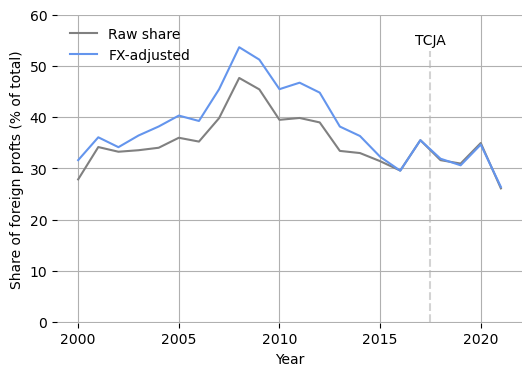

In [18]:
# see in 4b

In [12]:
# === DATA PROCESSING (3/3): READ & CLEAN BUSINESS CYCLE ===
# Build World/US/ROW GDP levels & growth (WB), and USD index change (FRED).

INDICATOR = {"NY.GDP.MKTP.KD": "gdp_constant_usd"}
START_YEAR, END_YEAR = 1982, datetime.now().year

# World Bank (WLD, USA)
df_sel = wb.get_dataframe(INDICATOR, country=["WLD", "USA"]).dropna()
# Normalize to year column
if "date" in df_sel.index.names:
    df_sel = df_sel.reset_index().rename(columns={"date": "year"})
    df_sel["year"] = pd.to_datetime(df_sel["year"]).dt.year
elif isinstance(df_sel.index, pd.DatetimeIndex):
    df_sel = df_sel.reset_index().rename(columns={"index": "year"})
    df_sel["year"] = df_sel["year"].dt.year
else:
    df_sel = df_sel.reset_index().rename(columns={df_sel.index.names[0]: "year"})

df_sel = df_sel[(df_sel["year"] >= START_YEAR) & (df_sel["year"] <= END_YEAR)]
df_piv = df_sel.pivot_table(index="year", columns="country", values="gdp_constant_usd").sort_index()
if "WLD" in df_piv.columns:  # keep stable names
    df_piv = df_piv.rename(columns={"WLD": "World", "USA": "United States"})

# ROW = World - US; growth in %
df_piv["ROW"] = df_piv["World"] - df_piv["United States"]
df_growth = df_piv.pct_change() * 100.0
df_growth.columns = [c.replace("United States", "US") + "_growth" for c in df_growth.columns]

# FRED broad USD index (percentage change); backfill missing with alternative series as in your script
fred = pd.read_csv(FRED_DOLLAR_INDEX_CSV, parse_dates=["observation_date"])
fred["year"] = fred["observation_date"].dt.year
fred_y = fred.groupby("year", as_index=True)[["DTWEXBGS_PCH", "DTWEXB_PCH", "DTWEXM_PCH"]].mean()
fred_y.loc[fred_y["DTWEXBGS_PCH"].isna(), "DTWEXBGS_PCH"] = fred_y.loc[fred_y["DTWEXBGS_PCH"].isna(), "DTWEXB_PCH"]
fred_y.loc[fred_y["DTWEXBGS_PCH"].isna(), "DTWEXBGS_PCH"] = fred_y.loc[fred_y["DTWEXBGS_PCH"].isna(), "DTWEXM_PCH"]

# === Build df_share_controls (as in your code) and SAVE ===
df_share_controls = pd.concat([df_cor, df_growth, fred_y], axis=1)
df_share_controls = df_share_controls.loc[:, ["share_raw", "ROW_growth", "US_growth", "DTWEXBGS_PCH"]]
df_share_controls.columns = ["share_raw", "row_growth", "us_growth", "price_index"]
df_share_controls = df_share_controls.sort_index().dropna()

out_path = "data/df_share_controls.csv"
df_share_controls.to_csv(out_path, index=True)  # index is 'year'
print(f"Saved df_share_controls to: {out_path}")

df_share_controls.head(10)


Saved df_share_controls to: data/df_share_controls.csv


,share_raw,row_growth,us_growth,price_index
1989,33.997279,3.665092,3.672238,4.27590
1994,25.860988,3.155536,4.029023,-1.64004
1995,29.246352,3.346762,2.684431,-5.66746
1996,27.735608,3.524721,3.772773,5.27488
1997,29.630547,3.783665,4.447128,7.10864
1998,25.611601,2.204290,4.483133,11.04527
1999,25.782202,3.110746,4.788425,0.23179
2000,27.867473,4.743696,4.077586,2.92952
2001,34.178459,2.463694,0.955538,5.39758
2002,33.263775,2.547245,1.700447,0.57408


In [20]:
#see in 4b

=== OLS ===
                            OLS Regression Results                            
Dep. Variable:              share_raw   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.719
Method:                 Least Squares   F-statistic:                     24.87
Date:                Sat, 27 Sep 2025   Prob (F-statistic):           1.12e-07
Time:                        20:11:10   Log-Likelihood:                -70.387
No. Observations:                  29   AIC:                             148.8
Df Residuals:                      25   BIC:                             154.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          35.7525      1.303     

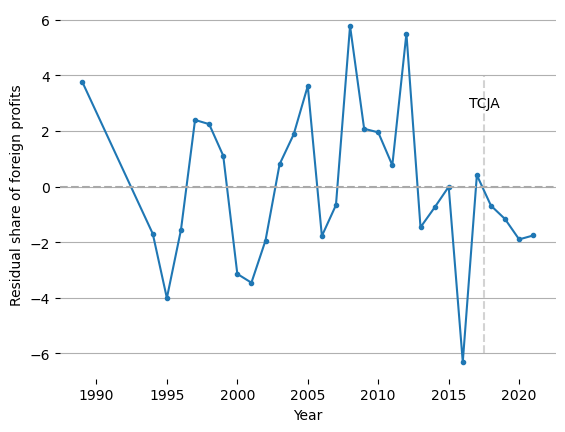

In [47]:
#see in 4b